In [1]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import MinMaxScaler, StandardScaler

sns.set_style("whitegrid")
pd.set_option("display.max_columns", 20)
pd.set_option("display.width", 140)

# ---- EDIT THESE PATHS IF YOUR FILES ARE ELSEWHERE ------------------------
DATA_DIR = "."                     # folder containing train.tsv / valid.tsv / test.tsv
OUT_DIR = "graphs"                 # where charts get saved
FINAL_CSV = "liar_engineered_dataset.csv"
os.makedirs(OUT_DIR, exist_ok=True)


def save(fig, name):
    """Save a figure to OUT_DIR and show it."""
    path = os.path.join(OUT_DIR, name)
    fig.savefig(path, dpi=120, bbox_inches="tight")
    print(f"[graph saved] {path}")
    plt.show()
    plt.close(fig)

In [2]:
# ===========================================================================
# 1. LOAD DATA  (original, unmodified LIAR .tsv files)
# ===========================================================================
print("\n" + "=" * 70)
print("STEP 1: LOAD DATA")
print("=" * 70)

COLS = ['id', 'label', 'statement', 'subject', 'speaker', 'job_title',
        'state', 'party', 'barely_true_c', 'false_c', 'half_true_c',
        'mostly_true_c', 'pants_fire_c', 'context']

train = pd.read_csv(os.path.join(DATA_DIR, "train.tsv"), sep="\t", header=None, names=COLS)
valid = pd.read_csv(os.path.join(DATA_DIR, "valid.tsv"), sep="\t", header=None, names=COLS)
test = pd.read_csv(os.path.join(DATA_DIR, "test.tsv"), sep="\t", header=None, names=COLS)

# tag original split so it can always be recovered later
train["split"] = "train"
valid["split"] = "valid"
test["split"] = "test"

df = pd.concat([train, valid, test], ignore_index=True)

print(f"train: {train.shape} | valid: {valid.shape} | test: {test.shape}")
print(f"combined df: {df.shape}")
print(df.head())

# OBSERVATION: all three splits share the same 14-column schema. Tagging
# each row with 'split' before concatenating means preprocessing / scaling
# is only written once but train/valid/test can still be separated later.



STEP 1: LOAD DATA
train: (10240, 15) | valid: (1284, 15) | test: (1267, 15)
combined df: (12791, 15)
           id        label                                          statement                             subject         speaker  \
0   2635.json        false  Says the Annies List political group supports ...                            abortion    dwayne-bohac   
1  10540.json    half-true  When did the decline of coal start? It started...  energy,history,job-accomplishments  scott-surovell   
2    324.json  mostly-true  Hillary Clinton agrees with John McCain "by vo...                      foreign-policy    barack-obama   
3   1123.json        false  Health care reform legislation is likely to ma...                         health-care    blog-posting   
4   9028.json    half-true  The economic turnaround started at the end of ...                        economy,jobs   charlie-crist   

              job_title     state       party  barely_true_c  false_c  half_true_c  mostly_true_c  

In [3]:
# ===========================================================================
# 2. PREPROCESSING — structure & basic cleanup
# ===========================================================================
print("\n" + "=" * 70)
print("STEP 2: PREPROCESSING (dtypes, text cleanup)")
print("=" * 70)

print("Shape:", df.shape)
print("\nColumn dtypes:\n", df.dtypes)

obj_cols = df.select_dtypes(include="object").columns.tolist()
for c in obj_cols:
    df[c] = df[c].astype(str).str.strip()
    df[c] = df[c].replace({"nan": np.nan, "None": np.nan, "": np.nan})

print("\nWhitespace trimmed / empty strings -> NaN for:", obj_cols)

# OBSERVATION: stripping whitespace and converting '' to NaN ensures the
# missing-value check below catches everything (pandas doesn't treat ''
# as missing by default).




STEP 2: PREPROCESSING (dtypes, text cleanup)
Shape: (12791, 15)

Column dtypes:
 id                object
label             object
statement         object
subject           object
speaker           object
job_title         object
state             object
party             object
barely_true_c    float64
false_c          float64
half_true_c      float64
mostly_true_c    float64
pants_fire_c     float64
context           object
split             object
dtype: object

Whitespace trimmed / empty strings -> NaN for: ['id', 'label', 'statement', 'subject', 'speaker', 'job_title', 'state', 'party', 'context', 'split']



STEP 3: MISSING VALUES
               missing_count  missing_%
job_title               3568      27.89
state                   2751      21.51
context                  131       1.02
subject                    2       0.02
speaker                    2       0.02
party                      2       0.02
barely_true_c              2       0.02
false_c                    2       0.02
half_true_c                2       0.02
mostly_true_c              2       0.02
pants_fire_c               2       0.02
[graph saved] graphs\01_missing_values.png


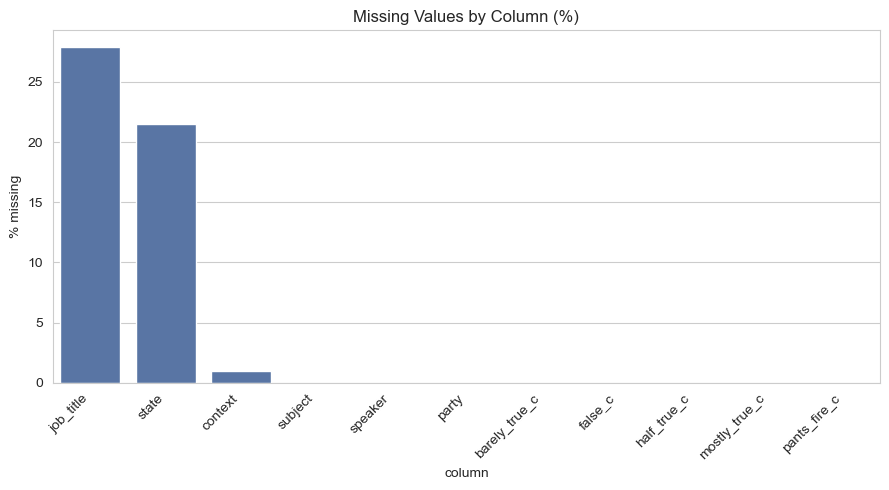

In [4]:
# ===========================================================================
# 3. MISSING VALUES
# ===========================================================================
print("\n" + "=" * 70)
print("STEP 3: MISSING VALUES")
print("=" * 70)

missing_count = df.isna().sum()
missing_pct = (missing_count / len(df) * 100).round(2)
missing_report = pd.DataFrame({"missing_count": missing_count, "missing_%": missing_pct})
missing_report = missing_report[missing_report["missing_count"] > 0].sort_values("missing_%", ascending=False)
print(missing_report)

fig, ax = plt.subplots(figsize=(9, 5))
sns.barplot(x=missing_report.index, y=missing_report["missing_%"], color="#4C72B0", ax=ax)
ax.set_title("Missing Values by Column (%)")
ax.set_ylabel("% missing")
ax.set_xlabel("column")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
save(fig, "01_missing_values.png")

# OBSERVATION: job_title / state typically have the most missing values
# (not every speaker has a formal title or mapped US state). The rest
# usually have only a handful of missing rows.

In [5]:
# ===========================================================================
# 4. DUPLICATES
# ===========================================================================
print("\n" + "=" * 70)
print("STEP 4: DUPLICATES")
print("=" * 70)

dup_all = df.duplicated().sum()
dup_id = df.duplicated(subset=["id"]).sum()
dup_statement = df.duplicated(subset=["statement"]).sum()
print(f"Fully duplicated rows      : {dup_all}")
print(f"Duplicated 'id' values     : {dup_id}")
print(f"Duplicated 'statement' text: {dup_statement}")

before = df.shape[0]
df = df.drop_duplicates(subset=["id"]).reset_index(drop=True)
after = df.shape[0]
print(f"Rows before de-dup: {before} | after: {after} | removed: {before - after}")

# OBSERVATION: de-duplicate on 'id' (the true primary key from the source
# .json files), NOT on 'statement' text — politicians legitimately repeat
# talking points, so identical statement text is not a duplicate record.



STEP 4: DUPLICATES
Fully duplicated rows      : 0
Duplicated 'id' values     : 0
Duplicated 'statement' text: 26
Rows before de-dup: 12791 | after: 12791 | removed: 0


In [15]:

# 5. NULL VALUE REMOVAL / IMPUTATION

print("\n" + "=" * 70)
print("STEP 5: NULL VALUE REMOVAL / IMPUTATION")
print("=" * 70)

core_cols = ["label", "statement", "party",
             "barely_true_c", "false_c", "half_true_c", "mostly_true_c", "pants_fire_c"]

before = df.shape[0]
df = df.dropna(subset=core_cols).reset_index(drop=True)
after = df.shape[0]
print(f"Rows before core-null removal: {before} | after: {after} | dropped: {before - after}")

impute_cols = ["job_title", "state", "context", "subject", "speaker"]
for c in impute_cols:
    df[c] = df[c].fillna("Unknown")

print("Remaining missing values:", df.isna().sum().sum())

# OBSERVATION: drop rows missing essential fields (label, statement, party,
# credit-history counts) — only a few rows affected. Impute sparse but
# non-critical categoricals with 'Unknown' rather than losing thousands
# of otherwise-usable rows.



STEP 5: NULL VALUE REMOVAL / IMPUTATION
Rows before core-null removal: 12789 | after: 12789 | dropped: 0
Remaining missing values: 0


In [7]:
# ===========================================================================
# 6. PREPROCESSING SUMMARY
# ===========================================================================
print("\n" + "=" * 70)
print("STEP 6: PREPROCESSING SUMMARY")
print("=" * 70)

orig_rows = train.shape[0] + valid.shape[0] + test.shape[0]
final_rows_pre_fe = df.shape[0]
summary = pd.DataFrame({
    "Metric": ["Original combined rows", "Rows removed (duplicates + core-nulls)",
               "Row count after cleaning", "Column count", "Remaining missing values"],
    "Value": [orig_rows, orig_rows - final_rows_pre_fe, final_rows_pre_fe,
              df.shape[1], int(df.isna().sum().sum())]
})
print(summary.to_string(index=False))




STEP 6: PREPROCESSING SUMMARY
                                Metric  Value
                Original combined rows  12791
Rows removed (duplicates + core-nulls)      2
              Row count after cleaning  12789
                          Column count     15
              Remaining missing values      0



STEP 7: LABEL COUNTS & PERCENTAGES
             count  percentage_%
label                           
half-true     2627         20.54
false         2505         19.59
mostly-true   2454         19.19
barely-true   2103         16.44
true          2053         16.05
pants-fire    1047          8.19
[graph saved] graphs\02_label_distribution.png


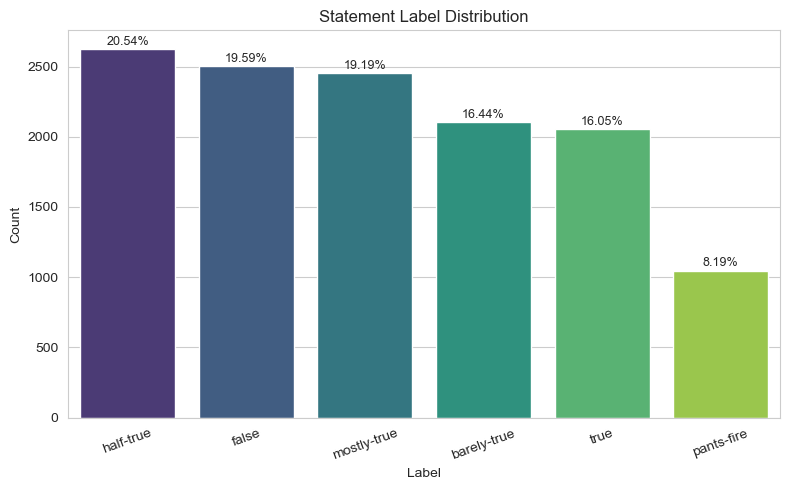

In [8]:
# ===========================================================================
# 7. LABEL COUNTS & PERCENTAGES
# ===========================================================================
print("\n" + "=" * 70)
print("STEP 7: LABEL COUNTS & PERCENTAGES")
print("=" * 70)

label_counts = df["label"].value_counts()
label_pct = (df["label"].value_counts(normalize=True) * 100).round(2)
label_summary = pd.DataFrame({"count": label_counts, "percentage_%": label_pct})
print(label_summary)

fig, ax = plt.subplots(figsize=(8, 5))
order = label_summary.index
sns.barplot(x=order, y=label_summary["count"], hue=order, palette="viridis",
            legend=False, ax=ax)
for i, (cnt, pct) in enumerate(zip(label_summary["count"], label_summary["percentage_%"])):
    ax.text(i, cnt + 30, f"{pct}%", ha="center", fontsize=9)
ax.set_title("Statement Label Distribution")
ax.set_ylabel("Count")
ax.set_xlabel("Label")
plt.xticks(rotation=20)
plt.tight_layout()
save(fig, "02_label_distribution.png")

# OBSERVATION: the 6 truthfulness labels are fairly balanced (roughly
# 9%-21% each), with 'half-true' the most common and 'pants-fire' the
# least common — no severe class imbalance to correct for.



STEP 8: FEATURE ENGINEERING
New engineered features: ['statement_char_len', 'statement_word_count', 'avg_word_length', 'total_history_count', 'credibility_score', 'is_true']
       statement_char_len  statement_word_count  avg_word_length  total_history_count  credibility_score       is_true
count        12789.000000          12789.000000     12789.000000          12789.00000       12789.000000  12789.000000
mean           107.114161             18.032919         5.993165             64.87802         -31.965478      0.352412
std             63.325827             10.108015         0.688358            115.75537          83.340191      0.477740
min             11.000000              2.000000         3.620000              0.00000        -411.500000      0.000000
25%             73.000000             12.000000         5.530000              2.00000         -17.000000      0.000000
50%             99.000000             17.000000         5.930000             11.00000          -3.000000      0

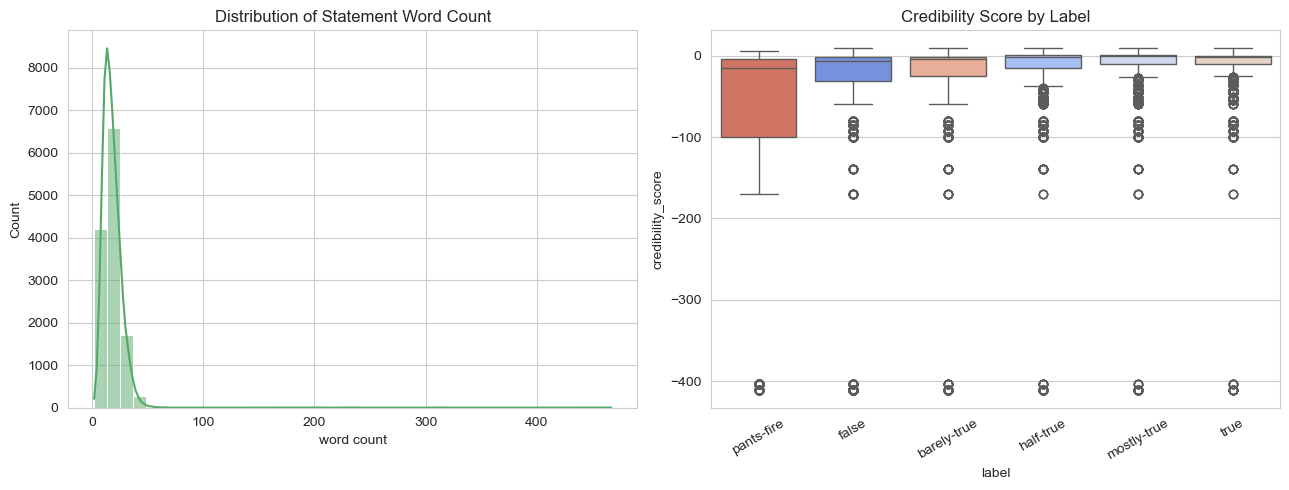

[graph saved] graphs\04_party_and_history.png


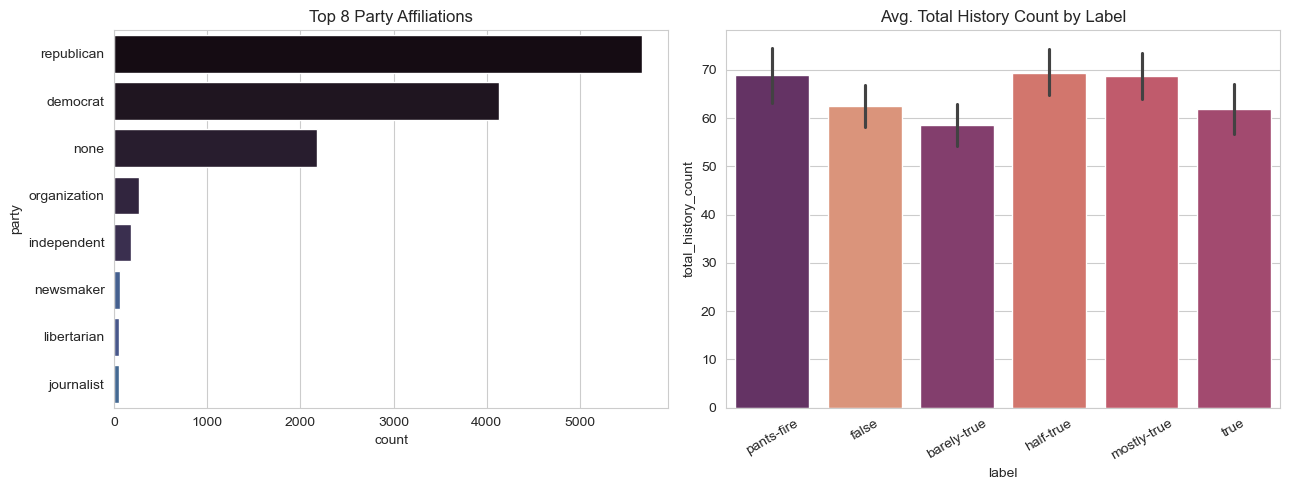

In [9]:
# ===========================================================================
# 8. FEATURE ENGINEERING
# ===========================================================================
print("\n" + "=" * 70)
print("STEP 8: FEATURE ENGINEERING")
print("=" * 70)

# -- text-based features --
df["statement_char_len"] = df["statement"].str.len()
df["statement_word_count"] = df["statement"].str.split().apply(len)
df["avg_word_length"] = (df["statement_char_len"] / df["statement_word_count"]).round(2)

# -- credit-history aggregate features --
count_cols = ["barely_true_c", "false_c", "half_true_c", "mostly_true_c", "pants_fire_c"]
df["total_history_count"] = df[count_cols].sum(axis=1)

# weighted credibility score: rewards true-leaning history, penalizes false-leaning history
weights = {"barely_true_c": -1, "false_c": -2, "half_true_c": 0.5,
           "mostly_true_c": 1, "pants_fire_c": -3}
df["credibility_score"] = sum(df[c] * w for c, w in weights.items())

# -- simplified binary target --
df["is_true"] = df["label"].isin(["mostly-true", "true"]).astype(int)

new_feats = ["statement_char_len", "statement_word_count", "avg_word_length",
             "total_history_count", "credibility_score", "is_true"]
print("New engineered features:", new_feats)
print(df[new_feats].describe())

# OBSERVATION: credibility_score is derived purely from a speaker's past
# record (not the current statement's label), so it's usable as a
# predictive feature without leaking the target.

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
sns.histplot(df["statement_word_count"], bins=40, kde=True, ax=axes[0], color="#55A868")
axes[0].set_title("Distribution of Statement Word Count")
axes[0].set_xlabel("word count")

label_order = ["pants-fire", "false", "barely-true", "half-true", "mostly-true", "true"]
sns.boxplot(x="label", y="credibility_score", data=df, order=label_order,
            hue="label", palette="coolwarm", legend=False, ax=axes[1])
axes[1].set_title("Credibility Score by Label")
axes[1].tick_params(axis="x", rotation=30)
plt.tight_layout()
save(fig, "03_wordcount_and_credibility.png")

# OBSERVATION: word count is right-skewed (most statements short, a few
# long). Credibility score rises monotonically from pants-fire -> true,
# confirming the engineered feature tracks the label well.

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
top_parties = df["party"].value_counts().iloc[:8].index
sns.countplot(y="party", data=df, order=top_parties, hue="party",
              palette="mako", legend=False, ax=axes[0])
axes[0].set_title("Top 8 Party Affiliations")

sns.barplot(x="label", y="total_history_count", data=df, order=label_order,
            estimator=np.mean, hue="label", palette="flare", legend=False, ax=axes[1])
axes[1].set_title("Avg. Total History Count by Label")
axes[1].tick_params(axis="x", rotation=30)
plt.tight_layout()
save(fig, "04_party_and_history.png")

# OBSERVATION: Republican/Democrat speakers dominate, as expected for US
# political fact-checking data. Total history count doesn't vary much by
# label -- it's the MIX of history (credibility_score), not raw volume,
# that differs.



STEP 9: CORRELATION ANALYSIS
                      barely_true_c  false_c  half_true_c  mostly_true_c  pants_fire_c  statement_char_len  statement_word_count  \
barely_true_c                  1.00     0.92         0.91           0.88          0.42               -0.04                 -0.03   
false_c                        0.92     1.00         0.76           0.71          0.65               -0.03                 -0.02   
half_true_c                    0.91     0.76         1.00           0.99          0.21               -0.03                 -0.02   
mostly_true_c                  0.88     0.71         0.99           1.00          0.16               -0.02                 -0.02   
pants_fire_c                   0.42     0.65         0.21           0.16          1.00               -0.01                 -0.01   
statement_char_len            -0.04    -0.03        -0.03          -0.02         -0.01                1.00                  0.98   
statement_word_count          -0.03    -0.02  

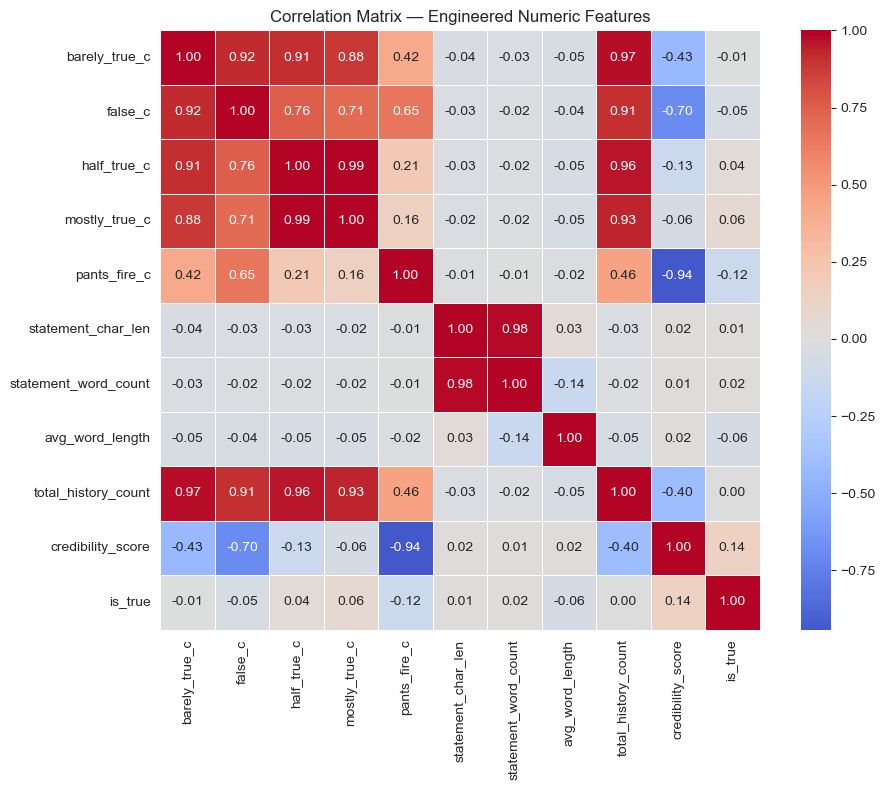

In [10]:
# ===========================================================================
# 9. CORRELATION
# ===========================================================================
print("\n" + "=" * 70)
print("STEP 9: CORRELATION ANALYSIS")
print("=" * 70)

numeric_cols = ["barely_true_c", "false_c", "half_true_c", "mostly_true_c", "pants_fire_c",
                "statement_char_len", "statement_word_count", "avg_word_length",
                "total_history_count", "credibility_score", "is_true"]

corr = df[numeric_cols].corr()
print(corr.round(2))

fig, ax = plt.subplots(figsize=(10, 8))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", center=0, square=True,
            linewidths=0.5, ax=ax)
ax.set_title("Correlation Matrix — Engineered Numeric Features")
plt.tight_layout()
save(fig, "05_correlation_heatmap.png")

# OBSERVATION: credibility_score correlates strongly with false_c /
# pants_fire_c by construction (expected, since it's built from them).
# Text-length features are nearly uncorrelated with the count columns,
# meaning they add independent, non-redundant signal.




STEP 10: MIN-MAX SCALING & STANDARDIZATION
Min-Max scaled ranges (should all be [0, 1]):
     barely_true_c_minmax  false_c_minmax  half_true_c_minmax  mostly_true_c_minmax  pants_fire_c_minmax  statement_char_len_minmax  \
min                   0.0             0.0                 0.0                   0.0                  0.0                        0.0   
max                   1.0             1.0                 1.0                   1.0                  1.0                        1.0   

     statement_word_count_minmax  avg_word_length_minmax  total_history_count_minmax  credibility_score_minmax  
min                          0.0                     0.0                         0.0                       0.0  
max                          1.0                     1.0                         1.0                       1.0  

Standardized stats (should all be mean~0, std~1):
      barely_true_c_zscore  false_c_zscore  half_true_c_zscore  mostly_true_c_zscore  pants_fire_c_zscore  stateme

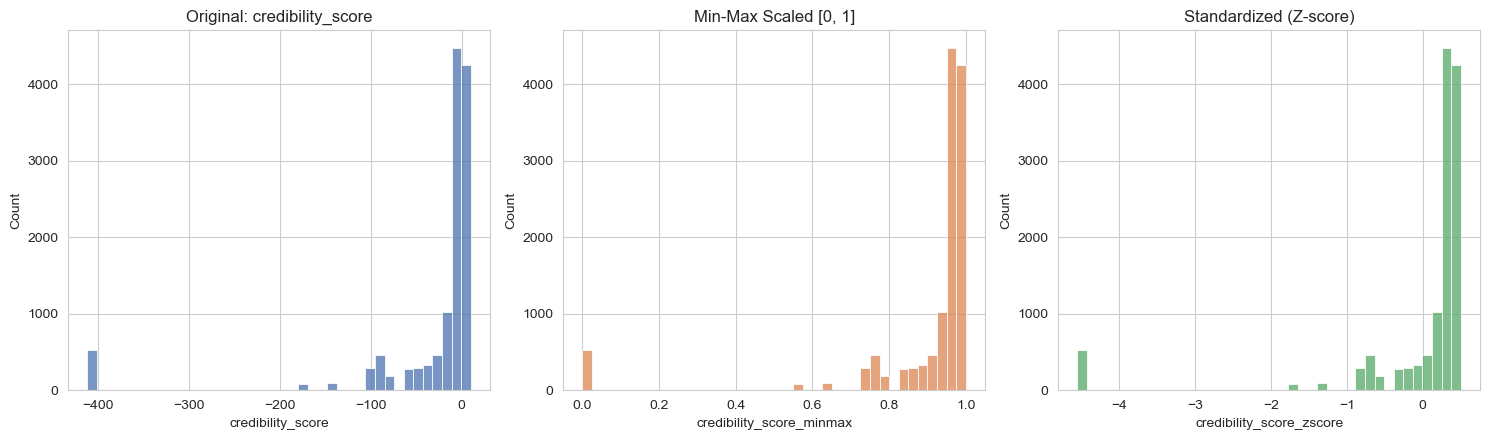

In [11]:
# ===========================================================================
# 10. SCALING — MIN-MAX & STANDARDIZATION
# ===========================================================================
print("\n" + "=" * 70)
print("STEP 10: MIN-MAX SCALING & STANDARDIZATION")
print("=" * 70)

scale_cols = ["barely_true_c", "false_c", "half_true_c", "mostly_true_c", "pants_fire_c",
              "statement_char_len", "statement_word_count", "avg_word_length",
              "total_history_count", "credibility_score"]

minmax = MinMaxScaler()
minmax_vals = minmax.fit_transform(df[scale_cols])
minmax_df = pd.DataFrame(minmax_vals, columns=[f"{c}_minmax" for c in scale_cols])

std = StandardScaler()
std_vals = std.fit_transform(df[scale_cols])
std_df = pd.DataFrame(std_vals, columns=[f"{c}_zscore" for c in scale_cols])

df = pd.concat([df.reset_index(drop=True), minmax_df, std_df], axis=1)

print("Min-Max scaled ranges (should all be [0, 1]):")
print(df[[f"{c}_minmax" for c in scale_cols]].agg(["min", "max"]).round(3))

print("\nStandardized stats (should all be mean~0, std~1):")
print(df[[f"{c}_zscore" for c in scale_cols]].agg(["mean", "std"]).round(3))

fig, axes = plt.subplots(1, 3, figsize=(15, 4.5))
sns.histplot(df["credibility_score"], bins=40, ax=axes[0], color="#4C72B0")
axes[0].set_title("Original: credibility_score")
sns.histplot(df["credibility_score_minmax"], bins=40, ax=axes[1], color="#DD8452")
axes[1].set_title("Min-Max Scaled [0, 1]")
sns.histplot(df["credibility_score_zscore"], bins=40, ax=axes[2], color="#55A868")
axes[2].set_title("Standardized (Z-score)")
plt.tight_layout()
save(fig, "06_scaling_comparison.png")

# OBSERVATION: scaling preserves the underlying shape/skew of the
# distribution -- only the axis range changes. Min-Max compresses to
# [0, 1]; standardization centers at mean 0, std 1.



In [14]:
# ===========================================================================
# 11. FINAL SUMMARY
# ===========================================================================
print("\n" + "=" * 70)
print("STEP 11: FINAL SUMMARY")
print("=" * 70)

final_summary = pd.DataFrame({
    "Metric": ["Final rows", "Final columns", "Original raw columns",
               "Engineered features added", "Scaled feature columns added",
               "Missing values", "Duplicate ids", "Label classes", "Splits preserved"],
    "Value": [df.shape[0], df.shape[1], 14, len(new_feats), len(scale_cols) * 2,
              int(df.isna().sum().sum()), int(df.duplicated(subset=["id"]).sum()),
              df["label"].nunique(), df["split"].nunique()]
})
print(final_summary.to_string(index=False))
print("\nFinal column list:")
print(list(df.columns))

# OBSERVATION: the pipeline took the raw 14-column LIAR files through
# cleaning, null handling, feature engineering, and dual scaling to
# produce a fully numeric-ready dataset with zero missing values and
# no duplicate ids.


STEP 11: FINAL SUMMARY
                      Metric  Value
                  Final rows  12789
               Final columns     41
        Original raw columns     14
   Engineered features added      6
Scaled feature columns added     20
              Missing values      0
               Duplicate ids      0
               Label classes      6
            Splits preserved      3

Final column list:
['id', 'label', 'statement', 'subject', 'speaker', 'job_title', 'state', 'party', 'barely_true_c', 'false_c', 'half_true_c', 'mostly_true_c', 'pants_fire_c', 'context', 'split', 'statement_char_len', 'statement_word_count', 'avg_word_length', 'total_history_count', 'credibility_score', 'is_true', 'barely_true_c_minmax', 'false_c_minmax', 'half_true_c_minmax', 'mostly_true_c_minmax', 'pants_fire_c_minmax', 'statement_char_len_minmax', 'statement_word_count_minmax', 'avg_word_length_minmax', 'total_history_count_minmax', 'credibility_score_minmax', 'barely_true_c_zscore', 'false_c_zscore', '

In [13]:
# ===========================================================================
# 12. FINAL ENGINEERED DATASET -> SAVE TO DISK
# ===========================================================================
print("\n" + "=" * 70)
print("STEP 12: SAVE FINAL ENGINEERED DATASET")
print("=" * 70)

print(df.head(10))

df.to_csv(FINAL_CSV, index=False)
print(f"\nFinal engineered dataset saved to: {os.path.abspath(FINAL_CSV)}")
print(f"Shape: {df.shape}")

# OBSERVATION: the final CSV includes original raw columns, the new
# engineered features, Min-Max + standardized versions of every numeric
# feature, and a 'split' column so train/valid/test can be recovered.


STEP 12: SAVE FINAL ENGINEERED DATASET
           id        label                                          statement                                    subject  \
0   2635.json        false  Says the Annies List political group supports ...                                   abortion   
1  10540.json    half-true  When did the decline of coal start? It started...         energy,history,job-accomplishments   
2    324.json  mostly-true  Hillary Clinton agrees with John McCain "by vo...                             foreign-policy   
3   1123.json        false  Health care reform legislation is likely to ma...                                health-care   
4   9028.json    half-true  The economic turnaround started at the end of ...                               economy,jobs   
5  12465.json         true  The Chicago Bears have had more starting quart...                                  education   
6   2342.json  barely-true  Jim Dunnam has not lived in the district he re...               